<a href="https://colab.research.google.com/github/yuvrajm4/261421_Introduction_To_ML_Safety/blob/main/exercise_solutions/Introduction_To_ML_Safety_Ex3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download and Extract the Dataset in G-Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os

DATASET_ROOT = "/content/drive/MyDrive/introduction_to_ml_safety"
os.makedirs(DATASET_ROOT, exist_ok=True)

# Download train and test split directly from OVGU cloud
!wget -q -O /content/drive/MyDrive/introduction_to_ml_safety/train.zip "https://cloud.ovgu.de/s/fYD35gBQA7Ykqom/download?path=%2F&files=train.zip"
!wget -q -O /content/drive/MyDrive/introduction_to_ml_safety/test.zip "https://cloud.ovgu.de/s/fYD35gBQA7Ykqom/download?path=%2F&files=test.zip"

print("Download finished.")

Download finished.


Extract Training and Test set

In [18]:


TRAIN_ZIP = os.path.join(DATASET_ROOT, "train.zip")
TEST_ZIP = os.path.join(DATASET_ROOT, "test.zip")


!unzip -q -o "$TRAIN_ZIP" -d /content/drive/MyDrive/introduction_to_ml_safety/
!unzip -q -o "$TEST_ZIP" -d /content/drive/MyDrive/introduction_to_ml_safety/

TRAIN_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/train"
TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"

print("Train folder exists:", os.path.exists(TRAIN_DIR))
print("Test folder exists:", os.path.exists(TEST_DIR))

Train folder exists: True
Test folder exists: True


Check files

In [21]:
for root, dirs, files in os.walk("/content/drive/MyDrive/introduction_to_ml_safety/train"):
    print(root, "->", len(files), "files")

/content/drive/MyDrive/introduction_to_ml_safety/train -> 9 files
/content/drive/MyDrive/introduction_to_ml_safety/train/rgb-front -> 7200 files
/content/drive/MyDrive/introduction_to_ml_safety/train/segmentation-front -> 7200 files
/content/drive/MyDrive/introduction_to_ml_safety/train/.hydra -> 3 files


# Checking Labels

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

train_df = pd.read_csv(os.path.join(TRAIN_DIR, "labels.csv"))
test_df = pd.read_csv(os.path.join(TEST_DIR, "labels.csv"))

print("Training labels:")
display(train_df.head())

print("Test labels:")
display(test_df.head())

Training labels:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


Test labels:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


In [23]:
FILENAME_COL = "frame"

LABELS = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]

print("Frame column:", FILENAME_COL)
print("Label columns:", LABELS)

Frame column: frame
Label columns: ['has_pedestrian', 'has_traffic_light', 'has_vehicle']


# 3.4 — Dataset Exploration

Load the CARLA dataset from Google Drive and explore the training and test splits.

1. Count how many images are in the training and test splits.

In [24]:
print("Number of training images:", len(train_df))
print("Number of test images:", len(test_df))

Number of training images: 7200
Number of test images: 3600


2. What is the class distribution for each label? Are the classes balanced?

--> count how many images contain the object (`True`) and how many do not (`False`)

In [25]:
for label in LABELS:
    print(f"\nClass distribution for {label}:")

    counts = train_df[label].value_counts().sort_index()
    percentages = train_df[label].value_counts(normalize=True).sort_index() * 100

    result = pd.DataFrame({
        "count": counts,
        "percentage": percentages.round(2)
    })

    display(result)


Class distribution for has_pedestrian:


,count,percentage
has_pedestrian,,
False,5482,76.14
True,1718,23.86



Class distribution for has_traffic_light:


,count,percentage
has_traffic_light,,
False,1924,26.72
True,5276,73.28



Class distribution for has_vehicle:


,count,percentage
has_vehicle,,
False,1742,24.19
True,5458,75.81


Plotting class distribution --> A balanced label would have similar numbers of `True` and `False` examples.  
If one class appears much more often than the other, the label is imbalanced.

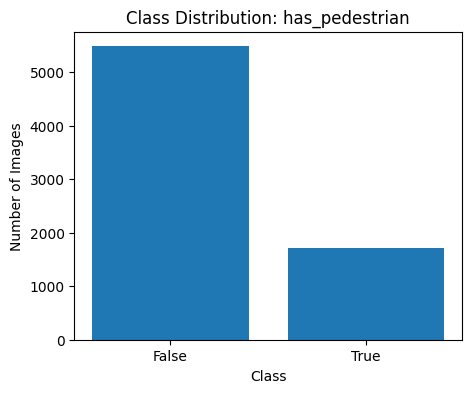

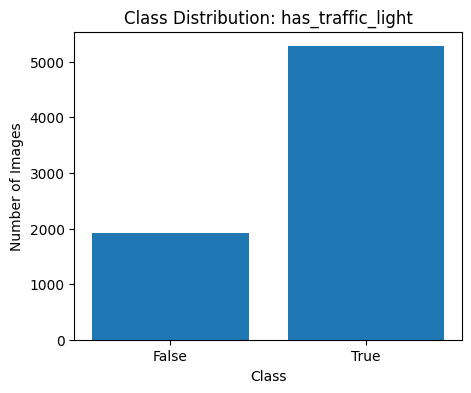

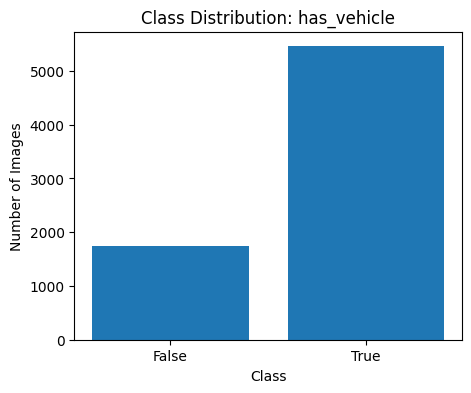

In [26]:
for label in LABELS:
    counts = train_df[label].value_counts().sort_index()

    plt.figure(figsize=(5, 4))
    plt.bar(counts.index.astype(str), counts.values)

    plt.title(f"Class Distribution: {label}")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")

    plt.show()

3. Example images - display random example images together with their labels.

Label combination counts:
combination
000     547
001    1063
010     832
011    3040
100      84
101     230
110     279
111    1125
Name: count, dtype: int64


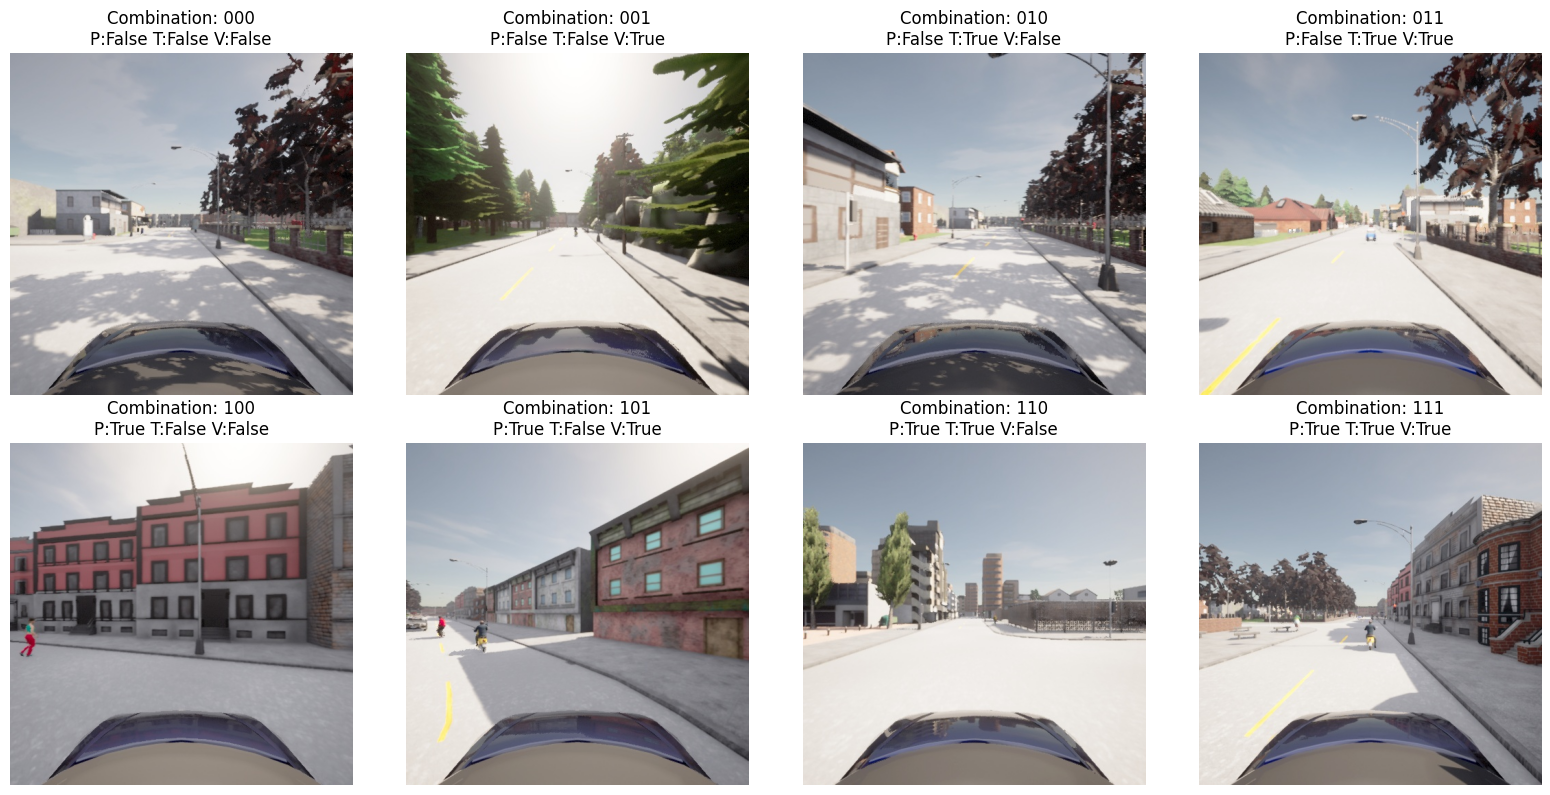

In [30]:
def build_image_path(root_dir, frame):

    # convert frame number into 6-digit filename
    filename = f"{int(frame):06d}.jpg"

    return os.path.join(
        root_dir,
        "rgb-front",
        filename
    )

train_df["combination"] = (
    train_df["has_pedestrian"].astype(int).astype(str) +
    train_df["has_traffic_light"].astype(int).astype(str) +
    train_df["has_vehicle"].astype(int).astype(str)
)

print("Label combination counts:")
print(train_df["combination"].value_counts().sort_index())


combinations = sorted(train_df["combination"].unique())

cols = 4
rows = int(np.ceil(len(combinations) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()

for i, combination in enumerate(combinations):
    example = train_df[train_df["combination"] == combination].iloc[0]

    img_path = build_image_path(TRAIN_DIR, example[FILENAME_COL])

    if img_path is None:
        axes[i].set_title(f"{combination}\nImage not found")
        axes[i].axis("off")
        continue

    img = Image.open(img_path).convert("RGB")

    axes[i].imshow(img)
    axes[i].axis("off")

    axes[i].set_title(
        f"Combination: {combination}\n"
        f"P:{example['has_pedestrian']} "
        f"T:{example['has_traffic_light']} "
        f"V:{example['has_vehicle']}"
    )

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Observations:

The dataset contains CARLA front-camera images with three Boolean labels: pedestrian presence, traffic light presence, and vehicle presence.

The number of images was obtained by counting the rows in the training and test label files.

The class distributions show that the dataset is not perfectly balanced. Vehicles appear frequently in many driving scenes, while pedestrians and traffic lights appear less often. This imbalance may make pedestrian and traffic light detection more difficult.

The displayed images mainly show urban driving situations. Vehicles are commonly visible on the road, traffic lights usually appear near intersections, and pedestrians appear less frequently, often near sidewalks or crossings.

The dataset mainly represents clear daytime driving conditions. From a safety perspective, this means that the dataset only supports claims for this limited Operational Design Domain. It does not provide strong evidence for performance in night, fog, rain, or other unseen conditions. This is related to hazard H-4, where autonomous mode remains active outside the intended ODD.


--------------------------------------------------------------------------------

3.5  Train Three Binary Classifiers
Train three separate binary classifiers on the training split – one for each detection task
(pedestrian, traffic light, vehicle). Use Python and preferably PyTorch. You may use a
pre-trained backbone (e.g., ResNet-18) and fine-tune it for binary classification. Commit
your code to your git repository.

In [38]:
import os

# Download validation split directly from OVGU cloud
!wget -q -O /content/drive/MyDrive/introduction_to_ml_safety/validation.zip "https://cloud.ovgu.de/s/fYD35gBQA7Ykqom/download?path=%2F&files=validation.zip"

print("Download finished.")

Download finished.


In [36]:
VALIDATION_ZIP = os.path.join(DATASET_ROOT, "validation.zip")


!unzip -q -o "$VALIDATION_ZIP" -d /content/drive/MyDrive/introduction_to_ml_safety/

VALIDATION_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/validation"

print("Validation folder exists:", os.path.exists(VALIDATION_DIR))

Validation folder exists: True


Validation Labels

In [40]:
val_df = pd.read_csv(os.path.join(VALIDATION_DIR, "labels.csv"))

print("Validation labels:")
display(val_df.head())

Validation labels:


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,True,False,0,178,10
1,10,True,False,False,347,0,2
2,20,True,False,False,347,0,0
3,30,True,False,False,347,0,0
4,40,True,False,False,347,0,0


## Model setup

1. Describe your model architecture and training setup (optimizer, learning rate, loss
function).

-->

Use ResNet-18 as a pre-trained backbone.  
The final layer is replaced by a single output neuron because each task is binary classification.

Training setup:
- Backbone: ResNet-18 -- is a lightweight and well-established convolutional neural network for image classification. Using a pre-trained backbone allows the model to reuse visual features learned from ImageNet, which improves convergence and reduces training time.

- Loss function: Binary Cross Entropy with Logits Loss -- it is appropriate for binary classification and combines sigmoid activation with binary cross-entropy loss in a numerically stable implementation.

- Optimizer: Adam -- it usually works well for fine-tuning neural networks and adapts the learning rate for each parameter.

- Learning rate: 0.0001 --A small learning rate of `0.0001` is used to avoid destroying the useful pre-trained features too quickly.

- Batch size: 32 -- provides a reasonable balance between stable gradient updates and GPU memory usage.

- Epochs: 5 -- The number of epochs was kept small to focusis on training baseline models rather than maximizing performance.

In [41]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class CarlaBinaryDataset(Dataset):
    def __init__(self, dataframe, root_dir, label_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = build_image_path(self.root_dir, row["frame"])
        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(
            float(row[self.label_column]),
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


Using device: cuda


Model Build Function

In [42]:
def create_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)

    return model.to(device)

Training Function

In [45]:
def train_binary_model(label_column, model_name, epochs=5, batch_size=32, lr=1e-4):

    train_dataset = CarlaBinaryDataset(
        train_df,
        TRAIN_DIR,
        label_column,
        transform=train_transform
    )

    val_dataset = CarlaBinaryDataset(
        val_df,
        VALIDATION_DIR,
        label_column,
        transform=val_transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    model = create_model()

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(
            f"{model_name} | Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )

    return model, train_losses, val_losses

## Train the pedestrian classifier

This model predicts whether a pedestrian is present in the image.

In [46]:
pedestrian_model, pedestrian_train_loss, pedestrian_val_loss = train_binary_model(
    label_column="has_pedestrian",
    model_name="Pedestrian Detector",
    epochs=5
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Pedestrian Detector | Epoch 1/5 | Train Loss: 0.4396 | Val Loss: 0.6308
Pedestrian Detector | Epoch 2/5 | Train Loss: 0.2898 | Val Loss: 0.7450
Pedestrian Detector | Epoch 3/5 | Train Loss: 0.1925 | Val Loss: 0.7776
Pedestrian Detector | Epoch 4/5 | Train Loss: 0.1260 | Val Loss: 0.9369
Pedestrian Detector | Epoch 5/5 | Train Loss: 0.0865 | Val Loss: 1.0303


## Train the traffic light classifier

This model predicts whether a traffic light is present in the image.

In [47]:
traffic_light_model, traffic_train_loss, traffic_val_loss = train_binary_model(
    label_column="has_traffic_light",
    model_name="Traffic Light Detector",
    epochs=5
)

Traffic Light Detector | Epoch 1/5 | Train Loss: 0.1391 | Val Loss: 0.0716
Traffic Light Detector | Epoch 2/5 | Train Loss: 0.0515 | Val Loss: 0.0827
Traffic Light Detector | Epoch 3/5 | Train Loss: 0.0289 | Val Loss: 0.0681
Traffic Light Detector | Epoch 4/5 | Train Loss: 0.0274 | Val Loss: 0.1004
Traffic Light Detector | Epoch 5/5 | Train Loss: 0.0218 | Val Loss: 0.0955


## Train the vehicle classifier

This model predicts whether a vehicle is present in the image.

In [48]:
vehicle_model, vehicle_train_loss, vehicle_val_loss = train_binary_model(
    label_column="has_vehicle",
    model_name="Vehicle Detector",
    epochs=5
)

Vehicle Detector | Epoch 1/5 | Train Loss: 0.3089 | Val Loss: 0.2987
Vehicle Detector | Epoch 2/5 | Train Loss: 0.1804 | Val Loss: 0.2929
Vehicle Detector | Epoch 3/5 | Train Loss: 0.1331 | Val Loss: 0.2985
Vehicle Detector | Epoch 4/5 | Train Loss: 0.1015 | Val Loss: 0.3302
Vehicle Detector | Epoch 5/5 | Train Loss: 0.0896 | Val Loss: 0.3278


Plot Loss Curves

2. Train each model and plot the training and validation loss curves. Do the models
converge?


-->

Vehicle Detector --

The vehicle detector shows strong learning behavior. The training loss decreases steadily from approximately 0.31 to below 0.10, indicating that the model successfully learns vehicle-related visual features.

However, the validation loss remains relatively high and slightly increases after later epochs. This suggests that the model begins to overfit the training data while generalization performance stops improving.

Overall, the model converges on the training set but shows mild overfitting.

Traffic Light Detector --

The traffic light detector shows the best overall behavior among the three models. Both training and validation losses remain relatively low throughout training.

The training loss decreases steadily, while the validation loss fluctuates only slightly and stays stable overall. This indicates that the model generalizes reasonably well to unseen data.

Therefore, the traffic light detector can be considered to have converged successfully without severe overfitting.

Pedestrian Detector --

The pedestrian detector behaves differently from the other two models. While the training loss decreases steadily, the validation loss continuously increases during training.

This indicates significant overfitting:

the model memorizes patterns from the training data,
but fails to generalize to unseen pedestrian examples.

This behavior is likely caused by:

class imbalance,
fewer pedestrian samples,
and greater visual variability of pedestrians.

From a safety perspective, this is especially important because pedestrian detection is directly related to hazard H-1 identified in the STPA analysis.

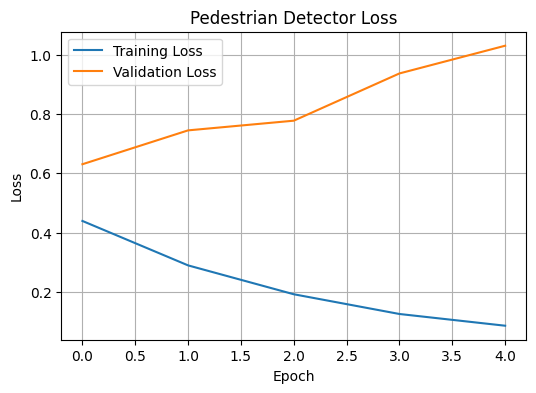

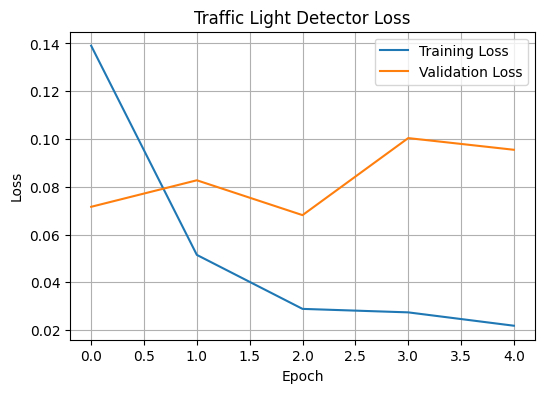

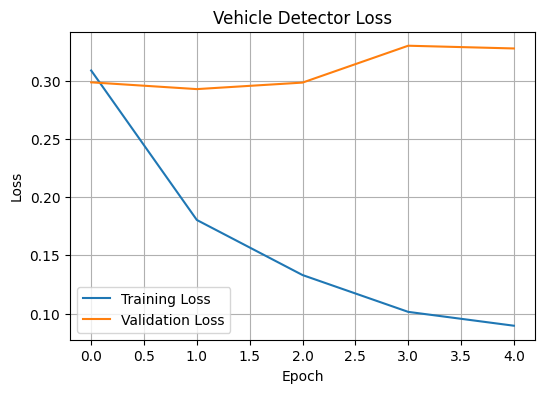

In [49]:
def plot_loss_curve(train_losses, val_losses, title):
    plt.figure(figsize=(6, 4))

    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_loss_curve(
    pedestrian_train_loss,
    pedestrian_val_loss,
    "Pedestrian Detector Loss"
)

plot_loss_curve(
    traffic_train_loss,
    traffic_val_loss,
    "Traffic Light Detector Loss"
)

plot_loss_curve(
    vehicle_train_loss,
    vehicle_val_loss,
    "Vehicle Detector Loss"
)

The models partially converge:

Vehicle and traffic light detectors show reasonable convergence behavior.
The pedestrian detector overfits and does not generalize well.

This demonstrates that convergence should not only be judged by training loss but also by validation performance.


---------------------------------------------------------------------------------------------------------------

Save Models

In [50]:
MODEL_SAVE_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

torch.save(
    pedestrian_model.state_dict(),
    os.path.join(MODEL_SAVE_DIR, "pedestrian_detector.pth")
)

torch.save(
    traffic_light_model.state_dict(),
    os.path.join(MODEL_SAVE_DIR, "traffic_light_detector.pth")
)

torch.save(
    vehicle_model.state_dict(),
    os.path.join(MODEL_SAVE_DIR, "vehicle_detector.pth")
)

print("Models saved successfully.")

Models saved successfully.


3. Why might training three separate models be preferable to a single multi-label
classifier from a safety perspective?

From a safety perspective, training three separate models can be preferable because each safety-critical perception task can be analyzed independently.

Each detector corresponds to different hazards identified earlier:

pedestrian detection → H-1,
traffic light detection → H-2,
vehicle detection → H-3.

Following are two reasons to use separate models.

Failure Isolation --

A failure in one detector does not directly affect the internal behavior of the other detectors.

Independent Safety Evaluation --

Each detector can be tested with task-specific metrics such as recall, false negatives, and precision.